<a href="https://colab.research.google.com/github/lenmecc/miniature-enigma/blob/main/Integrador3_Prophet_LSTM_S13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



### **Comparativo de los modelos Prophet, LSTM y Holt-Winters**

Usaremos la misma base de datos para contrastar los resultados aplicando estos tres algoritmos.

In [ ]:
# Instalando Prophet
!pip install prophet

In [ ]:
# Importando las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from math import sqrt


In [ ]:

# Preparando los datos
df = pd.read_csv('/content/AirPassengers.csv')
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])
df.set_index('ds', inplace=True)

In [ ]:
df

,y
ds,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
# ---------- Generando train y test ----------
train = df.iloc[:-12]
test = df.iloc[-12:]
dates = df.index
future_dates = test.index
historical_values = df['y'][:-12]
true_values = df['y'][-12:]

# ---------- ARIMA ----------
arima_model = ARIMA(train, order=(2, 1, 4))
arima_result = arima_model.fit()
arima_forecast_series = pd.Series(arima_result.forecast(steps=12), index=test.index)
rmse_arima = sqrt(mean_squared_error(test['y'], arima_forecast_series))

# ---------- Prophet ----------
prophet_df = df.reset_index()[['ds', 'y']]
train_prophet = prophet_df.iloc[:-12]
model_prophet = Prophet()
model_prophet.fit(train_prophet)
future_prophet = model_prophet.make_future_dataframe(periods=12, freq='MS')
forecast_prophet = model_prophet.predict(future_prophet)
forecast_prophet_series = forecast_prophet[['ds', 'yhat']].set_index('ds').iloc[-12:]
forecast_prophet_series.index = test.index
rmse_prophet = sqrt(mean_squared_error(test['y'], forecast_prophet_series['yhat']))

# ---------- Holt-Winters ----------
hw_model = ExponentialSmoothing(train['y'], trend='add', seasonal='add',seasonal_periods=12)
hw_fit = hw_model.fit()
hw_forecast_series = pd.Series(hw_fit.forecast(steps=12), index=test.index)
rmse_hw = sqrt(mean_squared_error(test['y'], hw_forecast_series))

# ---------- LSTM ----------
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['y']])
seq_length = 12
X_lstm, y_lstm = [], []
for i in range(len(scaled_data) - seq_length):
    X_lstm.append(scaled_data[i:i + seq_length])
    y_lstm.append(scaled_data[i + seq_length])
X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(seq_length, 1)))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_lstm, y_lstm, epochs=200, verbose=0)

last_sequence = scaled_data[-seq_length:]
predictions_lstm = []
current_input = last_sequence.reshape(1, seq_length, 1)
for _ in range(12):
    next_pred = model_lstm.predict(current_input, verbose=0)[0, 0]
    predictions_lstm.append(next_pred)
    current_input = np.append(current_input[:, 1:, :], [[[next_pred]]], axis=1)
forecast_lstm_series = pd.Series(
    scaler.inverse_transform(np.array(predictions_lstm).reshape(-1, 1)).flatten(),
    index=test.index
)
rmse_lstm = sqrt(mean_squared_error(test['y'], forecast_lstm_series))

# ---------- Creando la animación ----------
fig, ax = plt.subplots(figsize=(12, 6))

def animate(i):
    ax.clear()
    ax.plot(dates[:-12], historical_values, label="Datos Históricos", color="black")
    ax.plot(future_dates[:i+1], true_values[:i+1], label="Valores Reales", linestyle='--', color="gray")
    ax.plot(future_dates[:i+1], arima_forecast_series[:i+1], label=f"ARIMA (RMSE: {rmse_arima:.2f})", color="red", marker='o')
    ax.plot(future_dates[:i+1], forecast_prophet_series['yhat'][:i+1], label=f"Prophet (RMSE: {rmse_prophet:.2f})", color="purple", marker='D')
    ax.plot(future_dates[:i+1], hw_forecast_series[:i+1], label=f"Holt-Winters (RMSE: {rmse_hw:.2f})", color="blue", marker='s')
    ax.plot(future_dates[:i+1], forecast_lstm_series[:i+1], label=f"LSTM (RMSE: {rmse_lstm:.2f})", color="green", marker='^')
    ax.set_title("Pronóstico comparativo animado: ARIMA vs Prophet vs Holt-Winters vs LSTM")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Número de Pasajeros")
    ax.legend(loc='upper left')
    ax.grid(True)
    ax.set_xlim(dates[0], future_dates[-1])
    ymax = max(df['y'].max(),
               arima_forecast_series.max(),
               forecast_prophet_series['yhat'].max(),
               hw_forecast_series.max(),
               forecast_lstm_series.max())
    ax.set_ylim(0, ymax + 100)

ani = animation.FuncAnimation(fig, animate, frames=30, interval=1000, repeat=False)
plt.close(fig)

# Guardando GIF
ani.save('/content/forecast_comparison_4models_with_errors.gif', writer='pillow')


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals

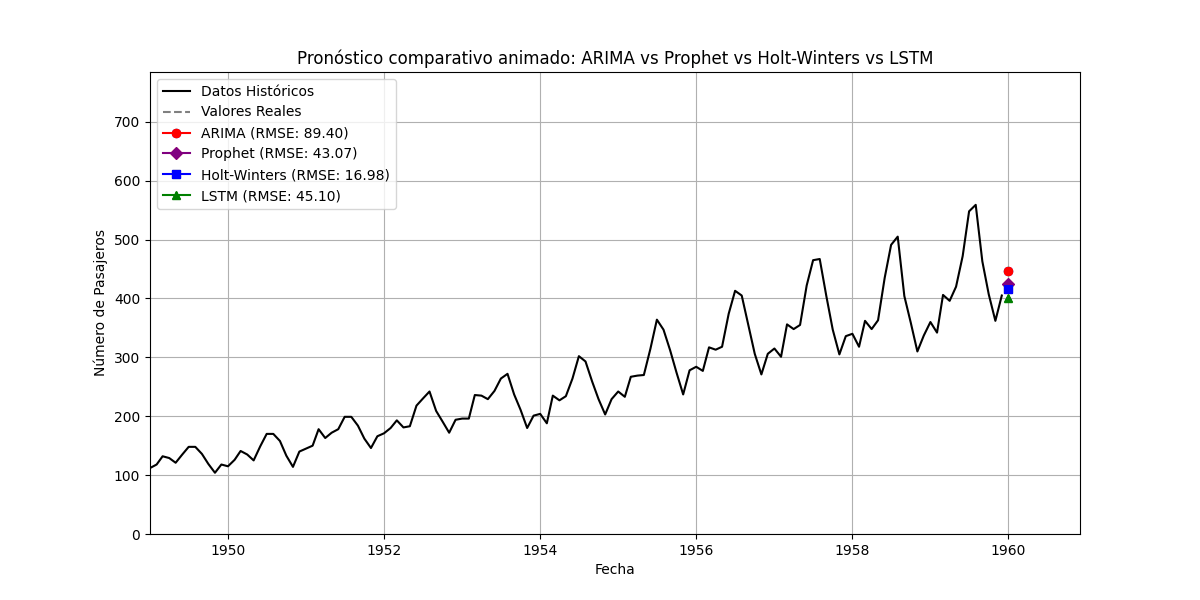

In [ ]:
from IPython.display import Image
Image(filename='/content/forecast_comparison_4models_with_errors.gif')

### **FINAL DEL NOTEBOOK**